In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
from scipy.spatial import cKDTree
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [118]:
# Reading the csv files
canopy_df = pd.read_csv('CanopInt_inst_data.csv')
esoil_df = pd.read_csv('ESoil_tavg_data.csv')
landcover_df = pd.read_csv('Land_cover_percent_data.csv')
rainfall_df = pd.read_csv('Rainf_tavg_data.csv')
snowfall_df = pd.read_csv('Snowf_tavg_data.csv')
tev_df = pd.read_csv('TVeg_tavg_data.csv')
tws_df = pd.read_csv('TWS_inst_data.csv')
yield_df = pd.read_csv('Yield_and_Production_data.csv')
lat_long_df = pd.read_csv('country_latitude_longitude_area_lookup.csv')
#soil moisture datasets
sm0_10_df = pd.read_csv('SoilMoi0_10cm_inst_data.csv')
sm10_40_df = pd.read_csv('SoilMoi10_40cm_inst_data.csv')
sm40_100_df = pd.read_csv('SoilMoi40_100cm_inst_data.csv')
sm100_200_df = pd.read_csv('SoilMoi100_200cm_inst_data.csv')
#soil temperature datasets
st0_10_df = pd.read_csv('SoilTMP0_10cm_inst_data.csv')
st10_40_df = pd.read_csv('SoilTMP10_40cm_inst_data.csv')
st40_100_df = pd.read_csv('SoilTMP40_100cm_inst_data.csv')
st100_200_df = pd.read_csv('SoilTMP100_200cm_inst_data.csv')


In [119]:
# Put all your dataframes in a dictionary for easy looping
all_dfs = {
    "canopy_df": canopy_df,
    "esoil_df": esoil_df,
    "landcover_df": landcover_df,
    "rainfall_df": rainfall_df,
    "snowfall_df": snowfall_df,
    "sm0_10_df": sm0_10_df,
    "sm10_40_df": sm10_40_df,
    "sm40_100_df": sm40_100_df,
    "sm100_200_df": sm100_200_df,
    "st0_10_df": st0_10_df,
    "st10_40_df": st10_40_df,
    "st40_100_df": st40_100_df,
    "st100_200_df": st100_200_df,
    "tev_df": tev_df,
    "tws_df": tws_df,
    "yield_df": yield_df,
    "lat_long_df": lat_long_df
}

# Loop through and print summary
for name, df in all_dfs.items():
    print(f"\n=== {name} ===")
    print(f"Shape: {df.shape}")
    print("Head:")
    print(df.head())



=== canopy_df ===
Shape: (194298, 15)
Head:
   longitude  latitude  CanopInt_inst_month_1  CanopInt_inst_month_2  \
0      -71.5     -54.5               0.102090               0.157268   
1      -70.5     -54.5               0.093179               0.132215   
2      -69.5     -54.5               0.092867               0.134192   
3      -68.5     -54.5               0.114641               0.156808   
4      -67.5     -54.5               0.132172               0.174698   

   CanopInt_inst_month_3  CanopInt_inst_month_4  CanopInt_inst_month_5  \
0               0.148165               0.134536               0.058467   
1               0.137757               0.126014               0.052497   
2               0.149097               0.124636               0.058634   
3               0.150524               0.127552               0.074838   
4               0.167903               0.153996               0.085783   

   CanopInt_inst_month_6  CanopInt_inst_month_7  CanopInt_inst_month_8  \
0  

In [120]:
#printing the coulumns of all the dataset
for name, df in all_dfs.items():
    print(f"\n=== {name} ===")
    print("Columns:", df.columns.tolist())



=== canopy_df ===
Columns: ['longitude', 'latitude', 'CanopInt_inst_month_1', 'CanopInt_inst_month_2', 'CanopInt_inst_month_3', 'CanopInt_inst_month_4', 'CanopInt_inst_month_5', 'CanopInt_inst_month_6', 'CanopInt_inst_month_7', 'CanopInt_inst_month_8', 'CanopInt_inst_month_9', 'CanopInt_inst_month_10', 'CanopInt_inst_month_11', 'CanopInt_inst_month_12', 'year']

=== esoil_df ===
Columns: ['longitude', 'latitude', 'ESoil_tavg_month_1', 'ESoil_tavg_month_2', 'ESoil_tavg_month_3', 'ESoil_tavg_month_4', 'ESoil_tavg_month_5', 'ESoil_tavg_month_6', 'ESoil_tavg_month_7', 'ESoil_tavg_month_8', 'ESoil_tavg_month_9', 'ESoil_tavg_month_10', 'ESoil_tavg_month_11', 'ESoil_tavg_month_12', 'year']

=== landcover_df ===
Columns: ['longitude', 'latitude', 'year', 'Land_cover_percent_class_1', 'Land_cover_percent_class_2', 'Land_cover_percent_class_3', 'Land_cover_percent_classh_4', 'Land_cover_percent_class_5', 'Land_cover_percent_class_6', 'Land_cover_percent_class_7', 'Land_cover_percent_class_8', '

In [121]:
# Normalize all column names
for df in all_dfs.values():
    df.columns = df.columns.str.lower().str.strip()

In [122]:
#out of 17 datasets we will take 14 of them and average the data and create a seperate column for each dataset

dfs = {
    "canopy_df": canopy_df,
    "esoil_df": esoil_df,
    "rainfall_df": rainfall_df,
    "snowfall_df": snowfall_df,
    "sm0_10_df": sm0_10_df,
    "sm10_40_df": sm10_40_df,
    "sm40_100_df": sm40_100_df,
    "sm100_200_df": sm100_200_df,
    "st0_10_df": st0_10_df,
    "st10_40_df": st10_40_df,
    "st40_100_df": st40_100_df,
    "st100_200_df": st100_200_df,
    "tev_df": tev_df,
    "tws_df": tws_df,
}




In [123]:
# Start with any one of the environmental DataFrames
env_dfs = [df for name, df in dfs.items()
           if name not in ['yield_df', 'lat_long_df'] and
           {'latitude', 'longitude', 'year'}.issubset(df.columns)]

merged_df= env_dfs[0]

for df in env_dfs[1:]:
    merged_df = pd.merge(merged_df, df, on=['latitude', 'longitude', 'year'], how='outer')

print("Merged environmental dataset shape:", merged_df.shape)
merged_df.head()

Merged environmental dataset shape: (194298, 171)


,longitude,latitude,canopint_inst_month_1,canopint_inst_month_2,canopint_inst_month_3,canopint_inst_month_4,canopint_inst_month_5,canopint_inst_month_6,canopint_inst_month_7,canopint_inst_month_8,...,tws_inst_month_3,tws_inst_month_4,tws_inst_month_5,tws_inst_month_6,tws_inst_month_7,tws_inst_month_8,tws_inst_month_9,tws_inst_month_10,tws_inst_month_11,tws_inst_month_12
0,-71.5,-54.5,0.102090,0.157268,0.148165,0.134536,0.058467,0.035004,0.030734,0.034665,...,1367.934,1390.243,1415.379,1437.813,1446.323,1451.915,1447.663,1437.027,1415.876,1391.918
1,-71.5,-54.5,0.150245,0.203924,0.207941,0.137177,0.077647,0.053191,0.035569,0.036051,...,1385.068,1409.094,1434.663,1444.239,1448.608,1457.339,1445.636,1419.949,1402.847,1370.564
2,-71.5,-54.5,0.122838,0.076477,0.206650,0.102611,0.046766,0.027625,0.028871,0.027422,...,1352.166,1399.109,1410.747,1406.259,1418.679,1423.797,1433.686,1425.313,1409.382,1407.311
3,-71.5,-54.5,0.141621,0.161991,0.171919,0.110428,0.060223,0.050415,0.033200,0.026607,...,1398.061,1420.489,1426.621,1443.817,1454.978,1456.134,1433.552,1423.367,1407.439,1407.020
4,-71.5,-54.5,0.132596,0.205276,0.174072,0.146616,0.059850,0.066032,0.028562,0.038980,...,1412.934,1419.579,1428.319,1445.819,1459.665,1455.198,1455.574,1429.711,1405.649,1403.224


In [124]:


# Group all columns by shared base name
monthly_groups = {}

# Detect monthly columns and group them
for col in merged_df.columns:
    match = re.match(r"(.*)_month_\d+$", col)
    if match:
        base = match.group(1)
        monthly_groups.setdefault(base, []).append(col)

# Compute average for each group and add as new column
for base, cols in monthly_groups.items():
    merged_df[base + "_avg"] = merged_df[cols].mean(axis=1)

    #  drop the original 12 columns
    merged_df.drop(columns=cols, inplace=True)

print(f"Aggregated {len(monthly_groups)} variable groups into average columns.")


Aggregated 14 variable groups into average columns.


In [125]:
merged_df.head()

,longitude,latitude,year,canopint_inst_avg,esoil_tavg_avg,rainf_tavg_avg,snowf_tavg_avg,soilmoi0_10cm_inst_avg,soilmoi10_40cm_inst_avg,soilmoi40_100cm_inst_avg,soilmoi100_200cm_inst_avg,soiltmp0_10cm_inst_avg,soiltmp10_40cm_inst_avg,soiltmp40_100cm_inst_avg,soiltmp100_200cm_inst_avg,tveg_tavg_avg,tws_inst_avg
0,-71.5,-54.5,2010,0.085151,32.854129,0.000029,3.019042e-07,26.783010,80.720931,161.612975,269.236008,278.062800,278.037967,278.060492,278.098683,0.489381,1410.814167
1,-71.5,-54.5,2011,0.096444,34.052988,0.000029,6.894789e-08,26.762192,80.614918,161.707608,269.527125,278.249575,278.191017,278.168150,278.147717,1.394214,1415.268750
2,-71.5,-54.5,2012,0.079865,37.242941,0.000030,7.061816e-08,26.625223,80.450461,161.101392,267.964875,278.243167,278.251675,278.293867,278.341417,0.806097,1399.244000
3,-71.5,-54.5,2013,0.086731,39.587144,0.000033,2.334499e-07,27.130210,81.956629,164.220067,273.560458,278.726425,278.682033,278.680200,278.660350,1.001805,1421.613417
4,-71.5,-54.5,2014,0.093183,36.269631,0.000032,0.000000e+00,27.162028,81.974751,164.520100,274.459850,278.267133,278.230567,278.238667,278.258792,0.568620,1425.402000


In [126]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194298 entries, 0 to 194297
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   longitude                  194298 non-null  float64
 1   latitude                   194298 non-null  float64
 2   year                       194298 non-null  int64  
 3   canopint_inst_avg          194298 non-null  float64
 4   esoil_tavg_avg             194298 non-null  float64
 5   rainf_tavg_avg             194298 non-null  float64
 6   snowf_tavg_avg             194298 non-null  float64
 7   soilmoi0_10cm_inst_avg     194298 non-null  float64
 8   soilmoi10_40cm_inst_avg    194298 non-null  float64
 9   soilmoi40_100cm_inst_avg   194298 non-null  float64
 10  soilmoi100_200cm_inst_avg  194298 non-null  float64
 11  soiltmp0_10cm_inst_avg     194298 non-null  float64
 12  soiltmp10_40cm_inst_avg    194298 non-null  float64
 13  soiltmp40_100cm_inst_avg   19

In [127]:

country_lookup_df = lat_long_df.copy()

# Clean and rename columns in the country-centroid lookup table
country_lookup_df.columns = country_lookup_df.columns.str.strip()
country_lookup_df = country_lookup_df.rename(columns={
    'centroid latitude': 'latitude',
    'centroid longitude': 'longitude'
})

# Round lat/lon to 1 decimal to match grid resolution
country_lookup_df['latitude'] = country_lookup_df['latitude'].astype(float).round(1)
country_lookup_df['longitude'] = country_lookup_df['longitude'].astype(float).round(1)

# Remove rows with missing or infinite coordinates
country_lookup_df = country_lookup_df.dropna(subset=['latitude', 'longitude'])
country_lookup_df = country_lookup_df[
    np.isfinite(country_lookup_df['latitude']) & np.isfinite(country_lookup_df['longitude'])
]

# Round lat/lon in land cover data to same precision
landcover_df['latitude'] = landcover_df['latitude'].astype(float).round(1)
landcover_df['longitude'] = landcover_df['longitude'].astype(float).round(1)

# Build a KDTree using country centroid coordinates
centroid_coords = country_lookup_df[['latitude', 'longitude']].to_numpy()
tree = cKDTree(centroid_coords)

# Query nearest centroid for each land cover grid cell
landcover_coords = landcover_df[['latitude', 'longitude']].to_numpy()
_, nearest_idx = tree.query(landcover_coords)

# Assign country to each land cover row based on nearest centroid
landcover_df['country'] = country_lookup_df.iloc[nearest_idx].reset_index(drop=True)['country']


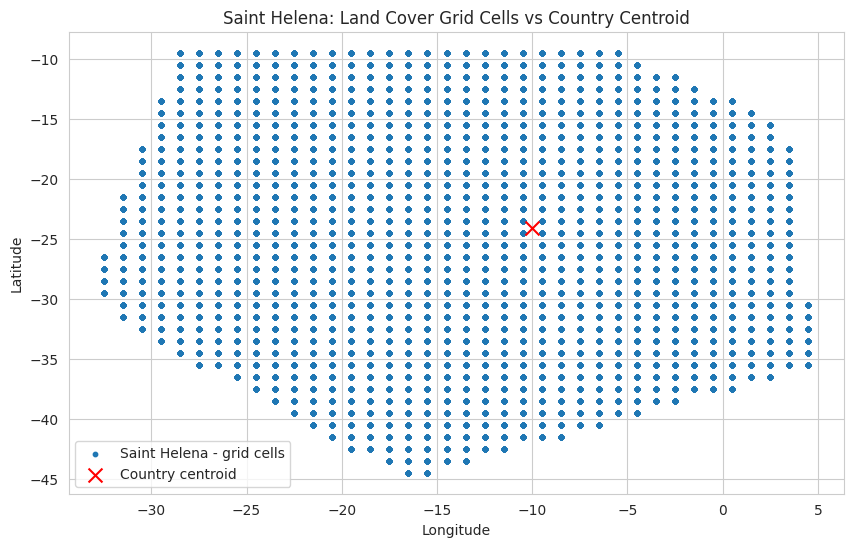

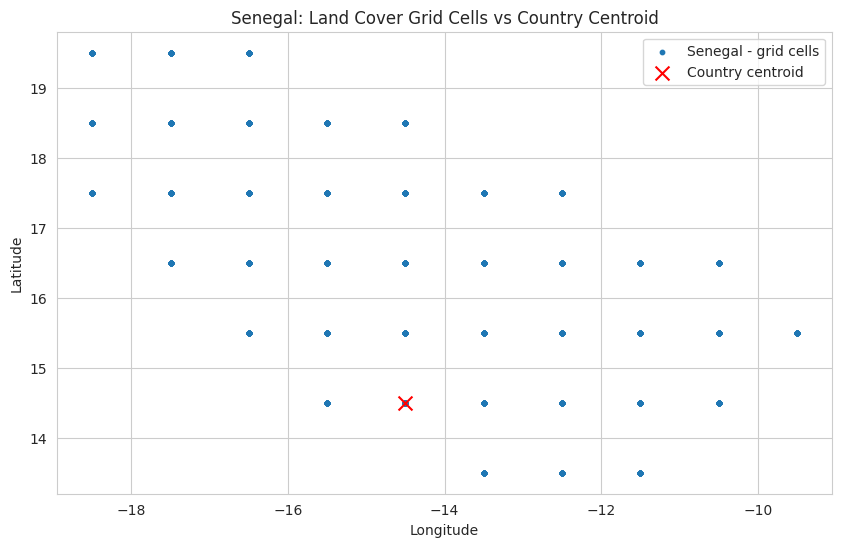

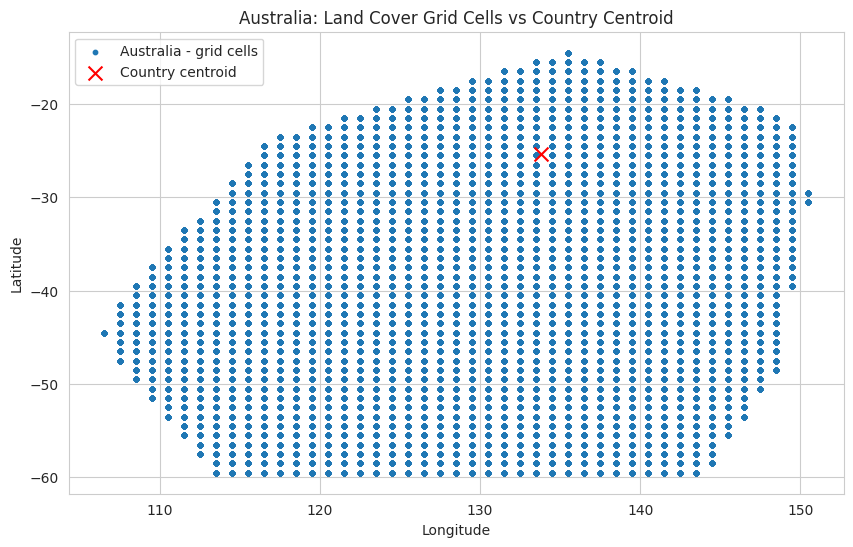

In [128]:


# Get common countries between land cover data and centroid lookup
landcover_countries = set(landcover_df['country'].dropna().unique())
centroid_countries = set(country_lookup_df['country'].dropna().unique())
shared_countries = sorted(landcover_countries & centroid_countries)

# Randomly pick 5 countries to visualize
sample_countries = random.sample(shared_countries, 3)

# Plot grid cell coverage vs. centroid for each selected country
for country in sample_countries:
    grid_cells = landcover_df[landcover_df['country'] == country]
    centroid = country_lookup_df[country_lookup_df['country'] == country]

    if grid_cells.empty or centroid.empty:
        continue

    plt.figure(figsize=(10, 6))
    plt.scatter(grid_cells['longitude'], grid_cells['latitude'], s=10, label=f"{country} - grid cells")
    plt.scatter(centroid['longitude'], centroid['latitude'], marker='x', s=100, color='red', label="Country centroid")

    plt.title(f"{country}: Land Cover Grid Cells vs Country Centroid")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.grid(True)
    plt.show()


In [129]:
# Group land cover data by country and year, averaging numeric features
landcover_country_year = landcover_df.groupby(['country', 'year']).mean(numeric_only=True).reset_index()

print("Aggregated land cover shape:", landcover_country_year.shape)
print(landcover_country_year[['country', 'year']].head())


Aggregated land cover shape: (3146, 21)
       country  year
0  Afghanistan  2010
1  Afghanistan  2011
2  Afghanistan  2012
3  Afghanistan  2013
4  Afghanistan  2014


In [130]:
# Use the same KDTree built from country_lookup_df
env_coords = merged_df[['latitude', 'longitude']].to_numpy()
_, nearest_indices = tree.query(env_coords)

# Assign country from nearest centroid
merged_df['country'] = country_lookup_df.iloc[nearest_indices].reset_index(drop=True)['country']

# Group by country and year to compute average environmental features
env_country_year = merged_df.groupby(['country', 'year']).mean(numeric_only=True).reset_index()

print("Environmental features aggregated by country and year:")
env_country_year.head(50)


Environmental features aggregated by country and year:


,country,year,longitude,latitude,canopint_inst_avg,esoil_tavg_avg,rainf_tavg_avg,snowf_tavg_avg,soilmoi0_10cm_inst_avg,soilmoi10_40cm_inst_avg,soilmoi40_100cm_inst_avg,soilmoi100_200cm_inst_avg,soiltmp0_10cm_inst_avg,soiltmp10_40cm_inst_avg,soiltmp40_100cm_inst_avg,soiltmp100_200cm_inst_avg,tveg_tavg_avg,tws_inst_avg
0,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,134.640014,240.593605,289.319155,289.317581,289.187112,288.908378,0.665504,688.719626
1,Afghanistan,2011,65.759259,33.666667,0.004174,17.658792,0.000008,1.733773e-06,17.474098,67.260410,132.755216,238.593572,289.398011,289.285327,289.169375,288.918274,0.293760,684.123852
2,Afghanistan,2012,65.759259,33.666667,0.004708,19.387013,0.000007,2.634706e-06,17.885093,68.767602,134.561956,239.145373,288.368113,288.356495,288.237801,288.069227,0.779504,699.515013
3,Afghanistan,2013,65.759259,33.666667,0.004051,20.860506,0.000008,1.361736e-06,18.206896,68.528548,135.918621,241.062339,289.715174,289.577175,289.413866,289.097295,0.850076,699.928255
4,Afghanistan,2014,65.759259,33.666667,0.004531,19.445957,0.000008,1.729525e-06,17.882212,68.116610,134.940831,239.098683,288.845817,288.725204,288.591054,288.418973,0.668922,695.321333
5,Afghanistan,2015,65.759259,33.666667,0.004474,22.961180,0.000011,1.474023e-06,18.852319,70.953128,141.179143,245.025223,289.681349,289.504648,289.323139,289.014696,1.169278,709.329171
6,Afghanistan,2016,65.759259,33.666667,0.003814,19.809441,0.000007,9.314142e-07,16.567422,69.327453,139.625471,244.822823,290.169079,290.091306,289.821877,289.422907,0.922003,698.939238
7,Afghanistan,2017,65.759259,33.666667,0.003465,16.211755,0.000006,2.087759e-06,15.956306,69.029705,138.388406,245.226235,289.616883,289.568854,289.425071,289.135256,0.500611,694.076992
8,Afghanistan,2018,65.759259,33.666667,0.003757,20.676496,0.000010,6.936727e-07,16.651093,69.360584,139.910498,245.674094,289.932216,289.858441,289.705743,289.384479,0.769348,683.863325
9,Afghanistan,2019,65.759259,33.666667,0.004949,21.521180,0.000009,2.900484e-06,19.009209,72.511858,144.816413,252.159056,288.714318,288.713155,288.618967,288.429901,1.024864,704.620740


In [131]:
env_country_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2548 entries, 0 to 2547
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    2548 non-null   object 
 1   year                       2548 non-null   int64  
 2   longitude                  2548 non-null   float64
 3   latitude                   2548 non-null   float64
 4   canopint_inst_avg          2548 non-null   float64
 5   esoil_tavg_avg             2548 non-null   float64
 6   rainf_tavg_avg             2548 non-null   float64
 7   snowf_tavg_avg             2548 non-null   float64
 8   soilmoi0_10cm_inst_avg     2548 non-null   float64
 9   soilmoi10_40cm_inst_avg    2548 non-null   float64
 10  soilmoi40_100cm_inst_avg   2548 non-null   float64
 11  soilmoi100_200cm_inst_avg  2548 non-null   float64
 12  soiltmp0_10cm_inst_avg     2548 non-null   float64
 13  soiltmp10_40cm_inst_avg    2548 non-null   float

In [132]:
# Merge country-year level environmental and land cover features
combined_features_df = env_country_year.merge(
    landcover_country_year,
    on=['country', 'year'],
    how='left'
)

print("Shape of combined feature dataset:", combined_features_df.shape)
print(combined_features_df[['country', 'year']].head(10))


Shape of combined feature dataset: (2548, 37)
       country  year
0  Afghanistan  2010
1  Afghanistan  2011
2  Afghanistan  2012
3  Afghanistan  2013
4  Afghanistan  2014
5  Afghanistan  2015
6  Afghanistan  2016
7  Afghanistan  2017
8  Afghanistan  2018
9  Afghanistan  2019


In [133]:
# Drop duplicate coordinate columns and standardize naming
combined_features_df = combined_features_df.drop(columns=['latitude_y', 'longitude_y'])
combined_features_df = combined_features_df.rename(columns={
    'latitude_x': 'latitude',
    'longitude_x': 'longitude'
})


In [134]:
combined_features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2548 entries, 0 to 2547
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      2548 non-null   object 
 1   year                         2548 non-null   int64  
 2   longitude                    2548 non-null   float64
 3   latitude                     2548 non-null   float64
 4   canopint_inst_avg            2548 non-null   float64
 5   esoil_tavg_avg               2548 non-null   float64
 6   rainf_tavg_avg               2548 non-null   float64
 7   snowf_tavg_avg               2548 non-null   float64
 8   soilmoi0_10cm_inst_avg       2548 non-null   float64
 9   soilmoi10_40cm_inst_avg      2548 non-null   float64
 10  soilmoi40_100cm_inst_avg     2548 non-null   float64
 11  soilmoi100_200cm_inst_avg    2548 non-null   float64
 12  soiltmp0_10cm_inst_avg       2548 non-null   float64
 13  soiltmp10_40cm_ins

In [135]:
yield_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158269 entries, 0 to 158268
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   domain           158269 non-null  object 
 1   country          158269 non-null  object 
 2   element          158269 non-null  object 
 3   item code (cpc)  158269 non-null  object 
 4   item             158269 non-null  object 
 5   year             158269 non-null  int64  
 6   value            158269 non-null  float64
 7   flag             158269 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 9.7+ MB


In [136]:
#import pandas as pd

In [137]:
yield_df = pd.read_csv('Yield_and_Production_data.csv')

In [138]:
# Step 1: Filter for 'Yield' rows
yield_data = yield_df[yield_df['Element'] == 'Yield'].copy()

# Step 2: Keep only relevant columns and rename
yield_data = yield_data[['Country', 'Item', 'Year', 'Value']]
yield_data.columns = ['country', 'crop', 'year', 'yield']

# Step 3: Merge with combined_features_df
final_df = pd.merge(combined_features_df, yield_data, on=['country', 'year'], how='inner')



In [139]:
final_df.head(10)

,country,year,longitude,latitude,canopint_inst_avg,esoil_tavg_avg,rainf_tavg_avg,snowf_tavg_avg,soilmoi0_10cm_inst_avg,soilmoi10_40cm_inst_avg,...,land_cover_percent_class_10,land_cover_percent_class_11,land_cover_percent_class_12,land_cover_percent_class_13,land_cover_percent_class_14,land_cover_percent_class_15,land_cover_percent_class_16,land_cover_percent_class_17,crop,yield
0,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Apples,7000.0
1,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Apricots,8000.0
2,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Barley,2061.3
3,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cantaloupes and other melons,9870.3
4,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Figs,4500.0
5,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Grapes,6494.1
6,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Linseed,671.1
7,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Maize (corn),1644.8
8,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Millet,3000.0
9,Afghanistan,2010,65.759259,33.666667,0.003434,17.406516,0.000007,9.650432e-07,16.522271,67.114595,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Olives,3318.2


In [140]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67963 entries, 0 to 67962
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      67963 non-null  object 
 1   year                         67963 non-null  int64  
 2   longitude                    67963 non-null  float64
 3   latitude                     67963 non-null  float64
 4   canopint_inst_avg            67963 non-null  float64
 5   esoil_tavg_avg               67963 non-null  float64
 6   rainf_tavg_avg               67963 non-null  float64
 7   snowf_tavg_avg               67963 non-null  float64
 8   soilmoi0_10cm_inst_avg       67963 non-null  float64
 9   soilmoi10_40cm_inst_avg      67963 non-null  float64
 10  soilmoi40_100cm_inst_avg     67963 non-null  float64
 11  soilmoi100_200cm_inst_avg    67963 non-null  float64
 12  soiltmp0_10cm_inst_avg       67963 non-null  float64
 13  soiltmp10_40cm_i

In [141]:
print("Final dataset shape:", final_df.shape)
print(final_df[['country', 'year', 'yield']].sample(5))
print(final_df.isnull().sum().sort_values(ascending=False).head(10))  # check for missing values


Final dataset shape: (67963, 37)
          country  year   yield
44879      Norway  2019  1429.6
5163   Bangladesh  2015  4551.8
67072       Yemen  2022  1138.5
53011      Serbia  2016  3101.0
60598     Tunisia  2017  6451.1
country                    0
year                       0
longitude                  0
latitude                   0
canopint_inst_avg          0
esoil_tavg_avg             0
rainf_tavg_avg             0
snowf_tavg_avg             0
soilmoi0_10cm_inst_avg     0
soilmoi10_40cm_inst_avg    0
dtype: int64


In [142]:
# See total nulls per column
missing_counts = final_df.isnull().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0])


Series([], dtype: int64)


In [143]:
# Count missing values (NaN or None) in each column
missing_info = final_df.isnull().sum()

# Filter to only show columns that have at least one missing value
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)

# Display the result
print("Columns with missing values:\n")
print(missing_info)


Columns with missing values:

Series([], dtype: int64)


No missing values or NaN values were found in the final dataset

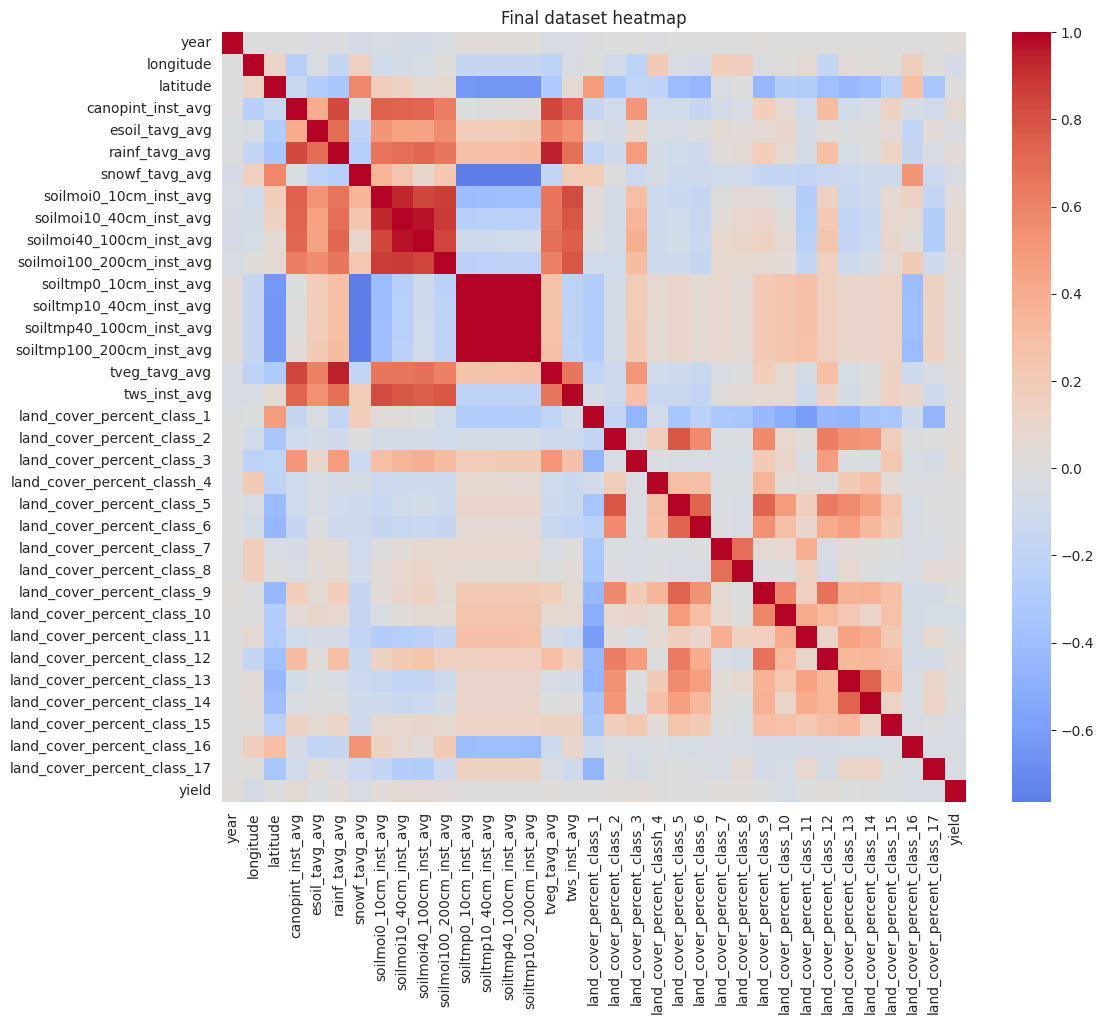

In [144]:

# Compute correlations
correlation_matrix = final_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Final dataset heatmap")
plt.show()


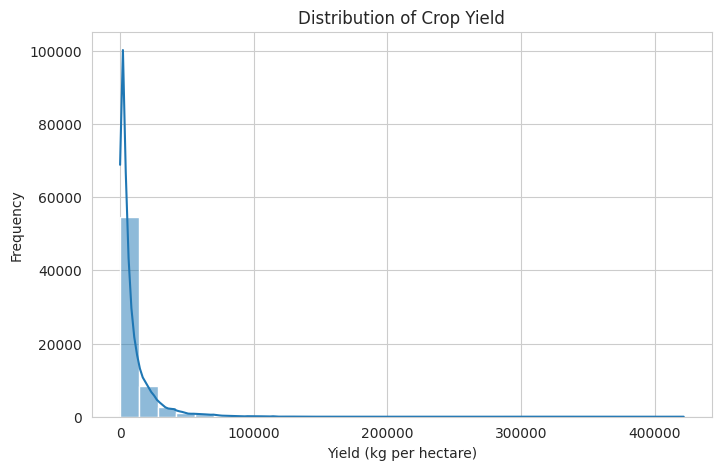

In [145]:
plt.figure(figsize=(8, 5))
sns.histplot(final_df['yield'], bins=30, kde=True)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg per hectare)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


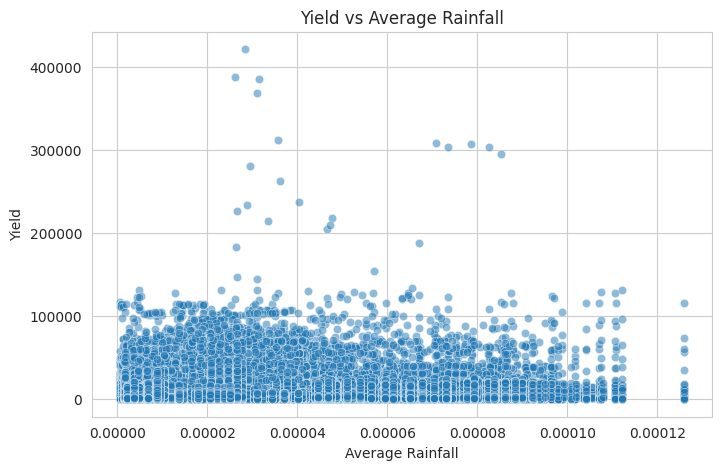

In [146]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=final_df, x='rainf_tavg_avg', y='yield', alpha=0.5)
plt.title("Yield vs Average Rainfall")
plt.xlabel("Average Rainfall")
plt.ylabel("Yield")
plt.grid(True)
plt.show()


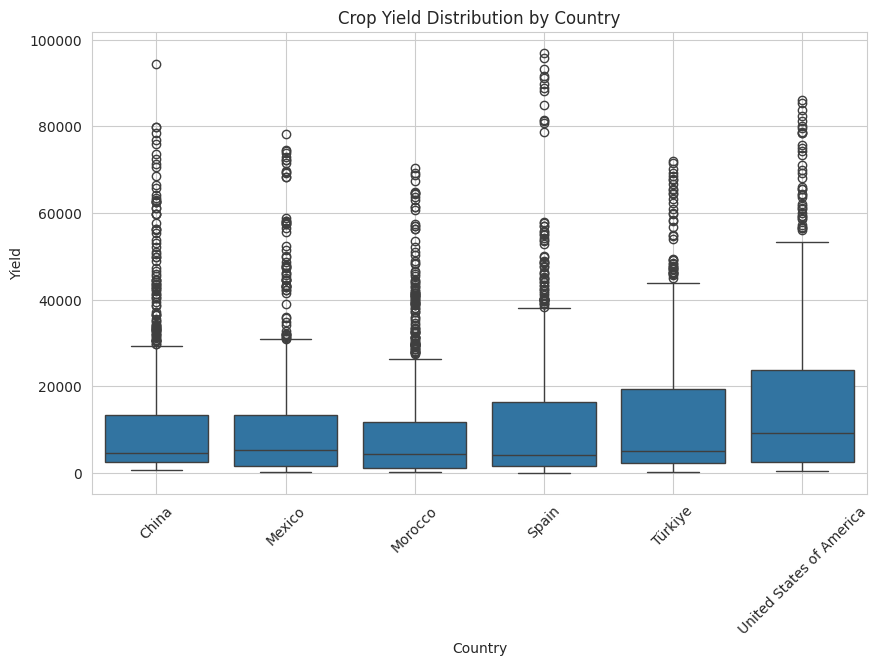

In [147]:
top_countries = final_df['country'].value_counts().head(6).index
subset = final_df[final_df['country'].isin(top_countries)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=subset, x='country', y='yield')
plt.title("Crop Yield Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Yield")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


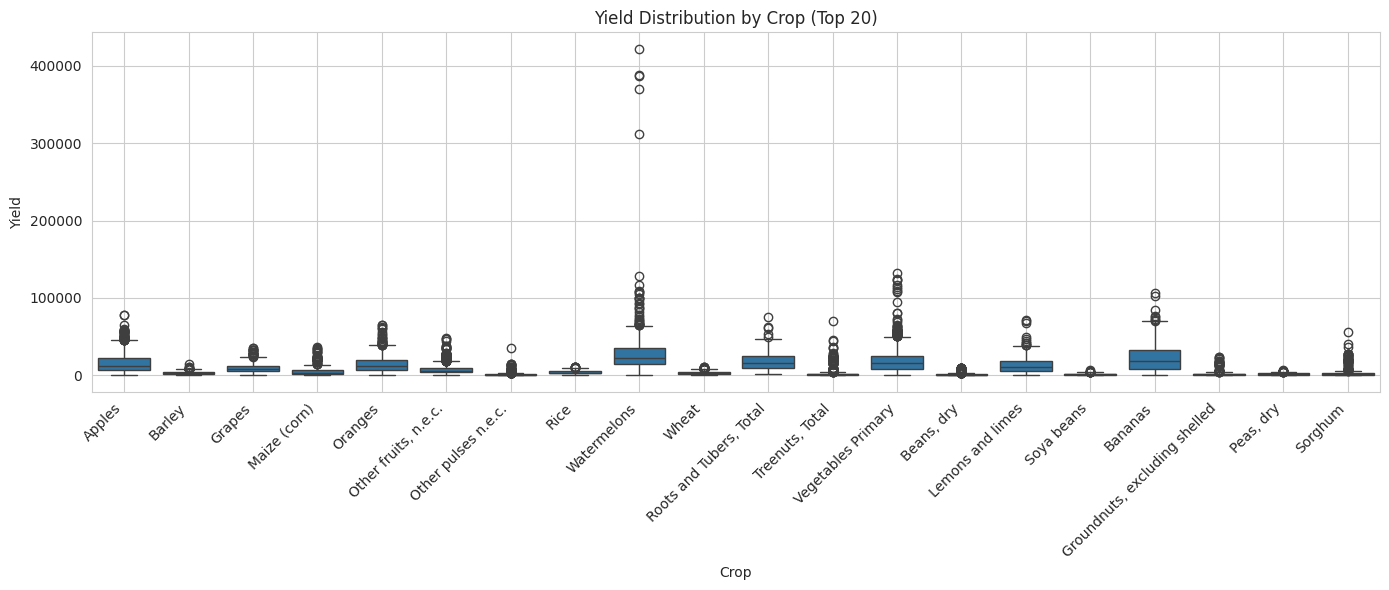

In [148]:

# You can change this to show all or limit to top N
crop_counts = final_df['crop'].value_counts()
top_n = 20  # change this to None to show all crops

if top_n:
    crops_to_plot = crop_counts.head(top_n).index
    df_crop_plot = final_df[final_df['crop'].isin(crops_to_plot)]
else:
    df_crop_plot = final_df

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_crop_plot, x='crop', y='yield')
plt.xticks(rotation=45, ha='right')
plt.title(f"Yield Distribution by Crop ({'Top ' + str(top_n) if top_n else 'All'})")
plt.xlabel("Crop")
plt.ylabel("Yield")
plt.tight_layout()
plt.grid(True)
plt.show()


## 2023 Prediction of crop yield

In [149]:


#  Create shifted dataset (yield of year y+1, features of year y)
df = final_df.copy().sort_values(['country', 'crop', 'year'])
df['future_yield'] = df.groupby(['country', 'crop'])['yield'].shift(-1)
df = df.dropna(subset=['future_yield'])

#  Define train_df and predict_df
train_df = df[df['year'] < 2022].copy()  # features from 2010–2021, targets 2011–2022
predict_df = final_df[final_df['year'] == 2022].copy()  # features from 2022 → forecast 2023

#  Define training target
y_train_log = np.log1p(train_df['future_yield'])

#  Feature preprocessing
def preprocess(df, scaler=None, fit=False, crop_cols=None, country_cols=None):
    num = df.select_dtypes(include=np.number).drop(columns=['yield', 'future_yield'], errors='ignore')
    if fit:
        scaler = MinMaxScaler()
        num_scaled = scaler.fit_transform(num)
    else:
        num_scaled = scaler.transform(num)

    crop = pd.get_dummies(df['crop'], prefix='crop')
    country = pd.get_dummies(df['country'], prefix='country')

    if crop_cols is not None:
        crop = crop.reindex(columns=crop_cols, fill_value=0)
    if country_cols is not None:
        country = country.reindex(columns=country_cols, fill_value=0)

    return np.hstack((num_scaled, crop.values, country.values)), crop.columns, country.columns, scaler

#  Preprocess training and 2022 features
X_train, crop_cols, country_cols, scaler = preprocess(train_df, fit=True)
X_2023, _, _, _ = preprocess(predict_df, scaler=scaler, crop_cols=crop_cols, country_cols=country_cols)

# Training   the model
model = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
model.fit(X_train, y_train_log)

# Predict for 2023
y_pred_2023 = np.expm1(model.predict(X_2023))  # invert log1p

# Prepare output
predict_df = predict_df.copy()
predict_df['predicted_yield_2023'] = y_pred_2023

# Merge with actual 2022 yield
output_df = predict_df[['country', 'crop', 'year', 'yield', 'predicted_yield_2023']].copy()
output_df.rename(columns={'year': 'year_2022', 'yield': 'actual_yield_2022'}, inplace=True)
output_df['year_2023'] = 2023

# Reorder columns
output_df = output_df[['country', 'crop', 'year_2022', 'actual_yield_2022', 'year_2023', 'predicted_yield_2023']]

# Save to CSV
output_df.to_csv("forecast_yield_2023.csv", index=False)
print(" Forecast for 2023 saved to 'forecast_yield_2023.csv'")

predicted_df = output_df

 Forecast for 2023 saved to 'forecast_yield_2023.csv'


In [150]:
# Check number of instances in training and prediction datasets
print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of prediction samples (2022 data for 2023 forecast): {X_2023.shape[0]}")


Number of training samples: 62498
Number of prediction samples (2022 data for 2023 forecast): 5190


In [151]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on training data to simulate past performance
y_train_pred_log = model.predict(X_train)
y_train_pred = np.expm1(y_train_pred_log)
y_train_true = np.expm1(y_train_log)

# Metrics
mae = mean_absolute_error(y_train_true, y_train_pred)
rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
r2 = r2_score(y_train_true, y_train_pred)

print("Evaluation metrics: ")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


Evaluation metrics: 
MAE : 1015.48
RMSE: 3223.85
R²  : 0.9505


In [152]:
#info about predicted dataset
predicted_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5190 entries, 366 to 67962
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               5190 non-null   object 
 1   crop                  5190 non-null   object 
 2   year_2022             5190 non-null   int64  
 3   actual_yield_2022     5190 non-null   float64
 4   year_2023             5190 non-null   int64  
 5   predicted_yield_2023  5190 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 283.8+ KB


In [153]:
#shape of the predicted dataset
predicted_df.shape

(5190, 6)

In [154]:
#printing first 10 entries of the predicted dataset
predicted_df.head(10)

,country,crop,year_2022,actual_yield_2022,year_2023,predicted_yield_2023
366,Afghanistan,Apples,2022,10600.0,2023,10230.372856
367,Afghanistan,Apricots,2022,7527.9,2023,6313.627545
368,Afghanistan,Barley,2022,1375.0,2023,1518.838291
369,Afghanistan,Cantaloupes and other melons,2022,10663.5,2023,12126.067264
370,Afghanistan,Figs,2022,4150.5,2023,5042.302058
371,Afghanistan,Grapes,2022,9784.9,2023,11509.158862
372,Afghanistan,Linseed,2022,906.3,2023,1188.459562
373,Afghanistan,Maize (corn),2022,2237.4,2023,2017.995077
374,Afghanistan,Millet,2022,1318.0,2023,1392.598353
375,Afghanistan,Mustard seed,2022,1033.0,2023,931.136858


In [155]:
predicted_df.to_csv('forecast_yield_2023.csv', index=False)

In [156]:
from google.colab import files
files.download('forecast_yield_2023.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## plots


In [157]:
# 1. Predict on training data
y_train_pred_log = model.predict(X_train)
y_train_pred = np.expm1(y_train_pred_log)
y_train_true = np.expm1(y_train_log)

# 2. Create DataFrame with metadata
train_meta = train_df[['country', 'crop', 'year']].copy()
train_meta['actual_yield_next_year'] = y_train_true
train_meta['predicted_yield_next_year'] = y_train_pred
train_meta['target_year'] = train_meta['year'] + 1  # year of predicted yield

# 3. Clean and reorder
train_meta.drop(columns=['year'], inplace=True)
train_meta = train_meta[['country', 'crop', 'target_year', 'actual_yield_next_year', 'predicted_yield_next_year']]

# 4. Save to CSV
train_meta.to_csv("historical_forecast_2011_2022.csv", index=False)
print("Saved historical yield forecasts to 'historical_forecast_2011_2022.csv'")


Saved historical yield forecasts to 'historical_forecast_2011_2022.csv'


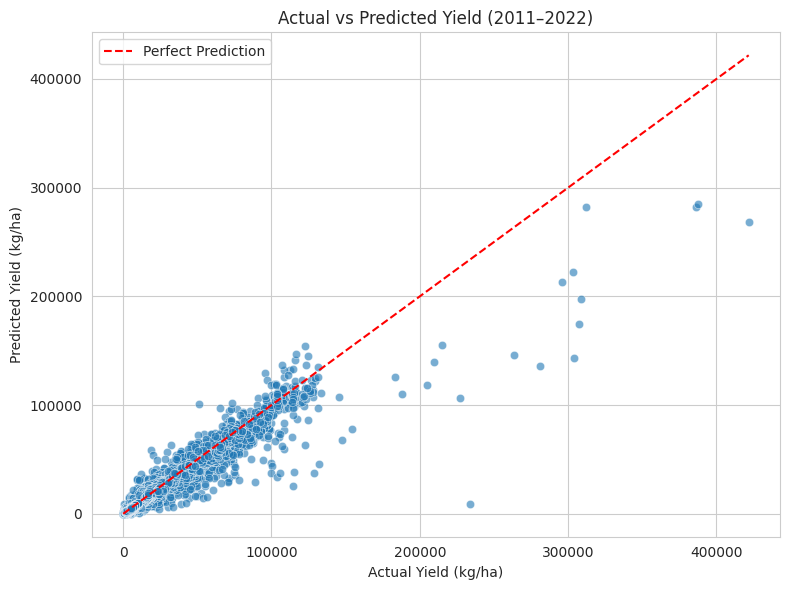

In [158]:


# Load saved predictions (optional if still in memory)
df = train_meta.copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='actual_yield_next_year', y='predicted_yield_next_year', data=df, alpha=0.6)
plt.plot([df['actual_yield_next_year'].min(), df['actual_yield_next_year'].max()],
         [df['actual_yield_next_year'].min(), df['actual_yield_next_year'].max()],
         linestyle='--', color='red', label='Perfect Prediction')
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title("Actual vs Predicted Yield (2011–2022)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


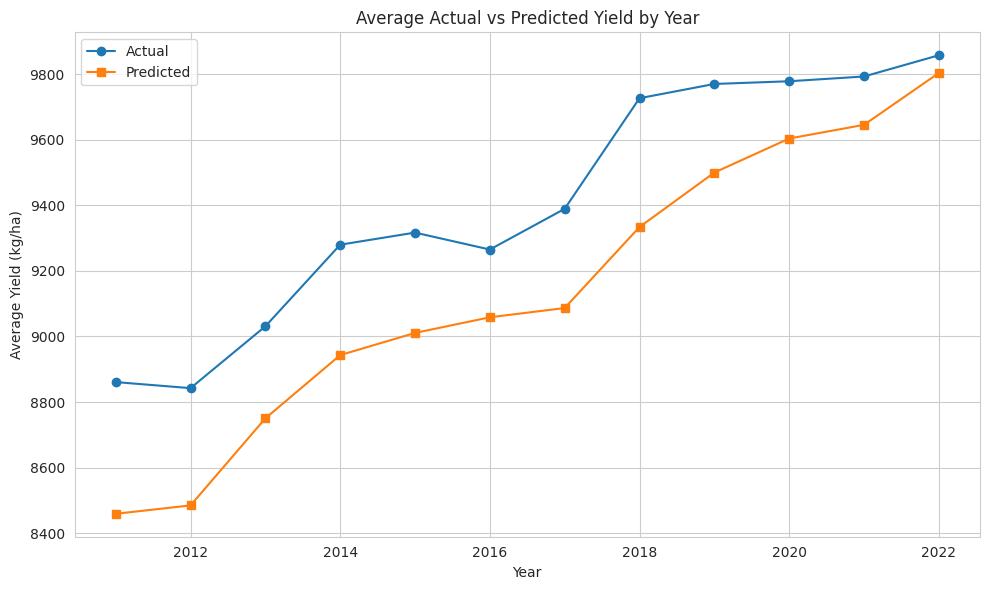

In [159]:
# Group by year and average
yearly = df.groupby('target_year')[['actual_yield_next_year', 'predicted_yield_next_year']].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(yearly['target_year'], yearly['actual_yield_next_year'], marker='o', label='Actual')
plt.plot(yearly['target_year'], yearly['predicted_yield_next_year'], marker='s', label='Predicted')
plt.xlabel("Year")
plt.ylabel("Average Yield (kg/ha)")
plt.title("Average Actual vs Predicted Yield by Year")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


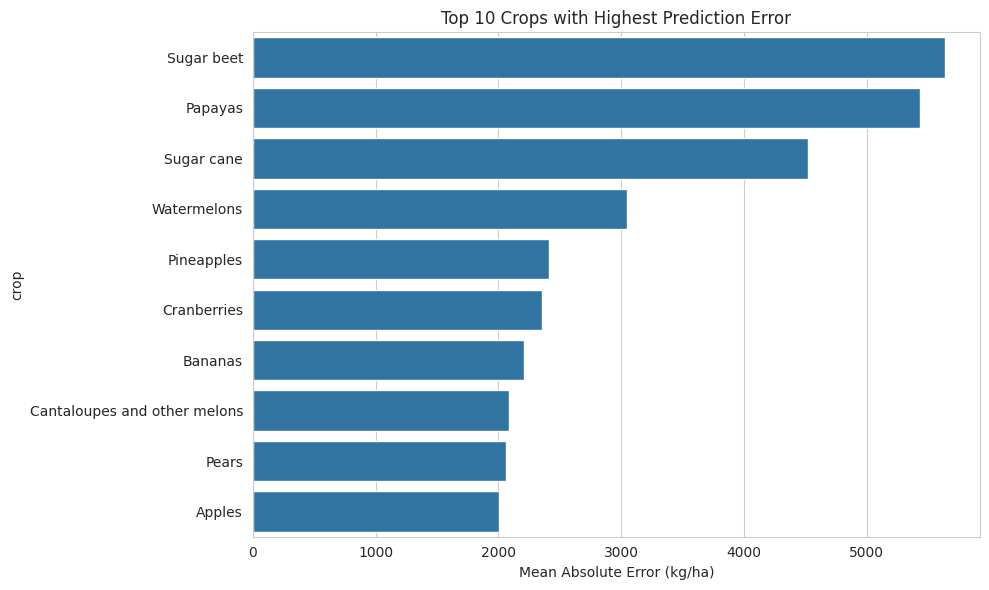

In [160]:
df['abs_error'] = abs(df['actual_yield_next_year'] - df['predicted_yield_next_year'])
top_crops = df.groupby('crop')['abs_error'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_crops.values, y=top_crops.index)
plt.xlabel("Mean Absolute Error (kg/ha)")
plt.title("Top 10 Crops with Highest Prediction Error")
plt.tight_layout()
plt.show()


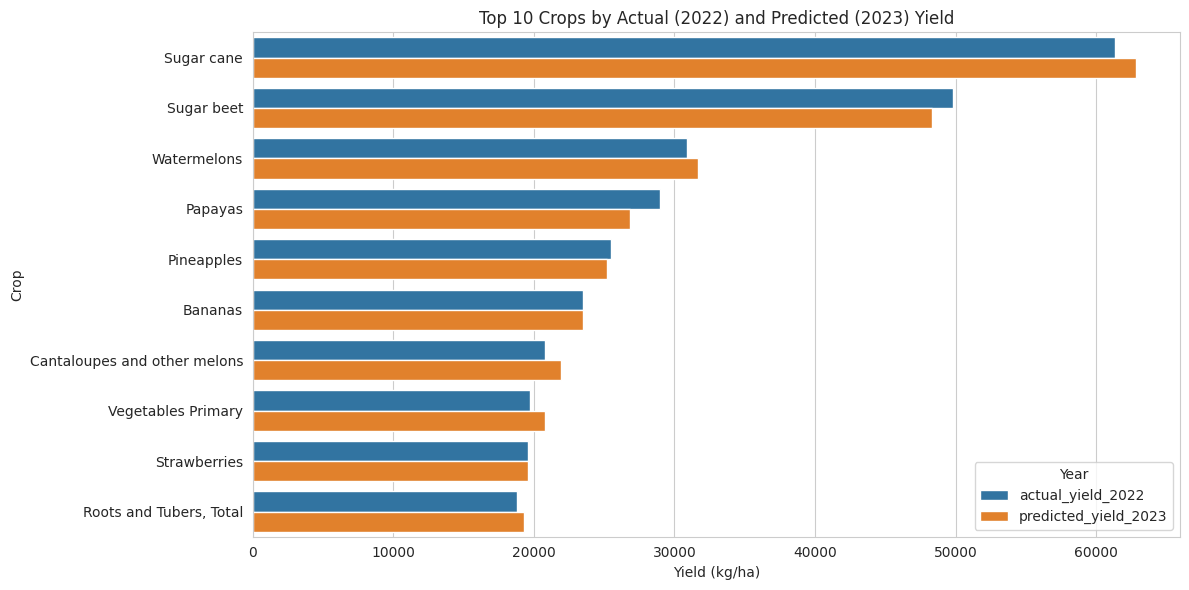

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Compute average yield per crop ---
mean_2022 = final_df[final_df['year'] == 2022] \
    .groupby('crop')['yield'].mean().rename('actual_yield_2022')

mean_2023 = output_df.groupby('crop')['predicted_yield_2023'] \
    .mean()

# --- Step 2: Combine into one DataFrame ---
combined = pd.concat([mean_2022, mean_2023], axis=1).dropna()

# --- Step 3: Get top 10 crops by 2022 yield ---
top_crops = combined.sort_values('actual_yield_2022', ascending=False).head(10)

# --- Step 4: Melt for seaborn barplot ---
melted = top_crops.reset_index().melt(id_vars='crop',
                                      value_vars=['actual_yield_2022', 'predicted_yield_2023'],
                                      var_name='year', value_name='yield')

# --- Step 5: Plot ---
plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x='yield', y='crop', hue='year')
plt.xlabel("Yield (kg/ha)")
plt.ylabel("Crop")
plt.title("Top 10 Crops by Actual (2022) and Predicted (2023) Yield")
plt.legend(title='Year')
plt.tight_layout()
plt.show()


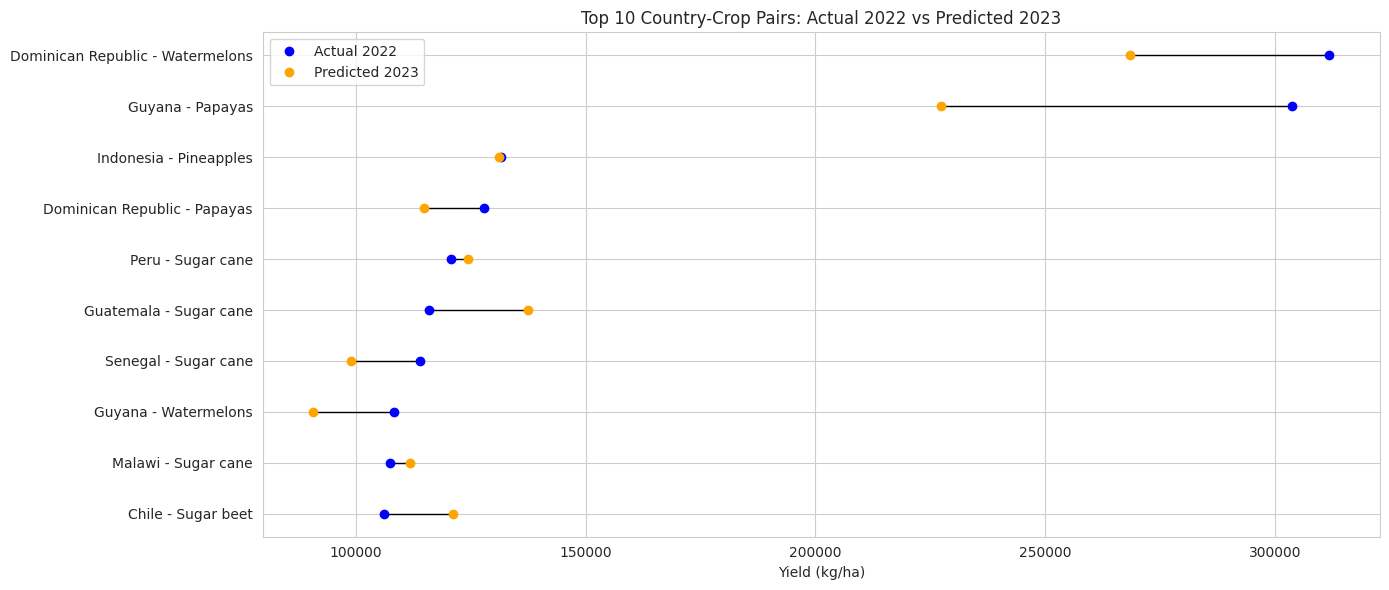

In [162]:

# Sort by actual_yield_2022 to preserve the same order
top_pairs_sorted = top_pairs.sort_values('actual_yield_2022', ascending=True)

# Plot
plt.figure(figsize=(14, 6))
for i, row in enumerate(top_pairs_sorted.itertuples()):
    plt.plot([row.actual_yield_2022, row.predicted_yield_2023], [i, i], 'k-', lw=1)  # line
    plt.plot(row.actual_yield_2022, i, 'o', label='Actual 2022' if i == 0 else "", color='blue')
    plt.plot(row.predicted_yield_2023, i, 'o', label='Predicted 2023' if i == 0 else "", color='orange')

plt.yticks(range(len(top_pairs_sorted)), top_pairs_sorted['pair'])
plt.xlabel("Yield (kg/ha)")
plt.title("Top 10 Country-Crop Pairs: Actual 2022 vs Predicted 2023")
plt.legend()
plt.tight_layout()
plt.show()

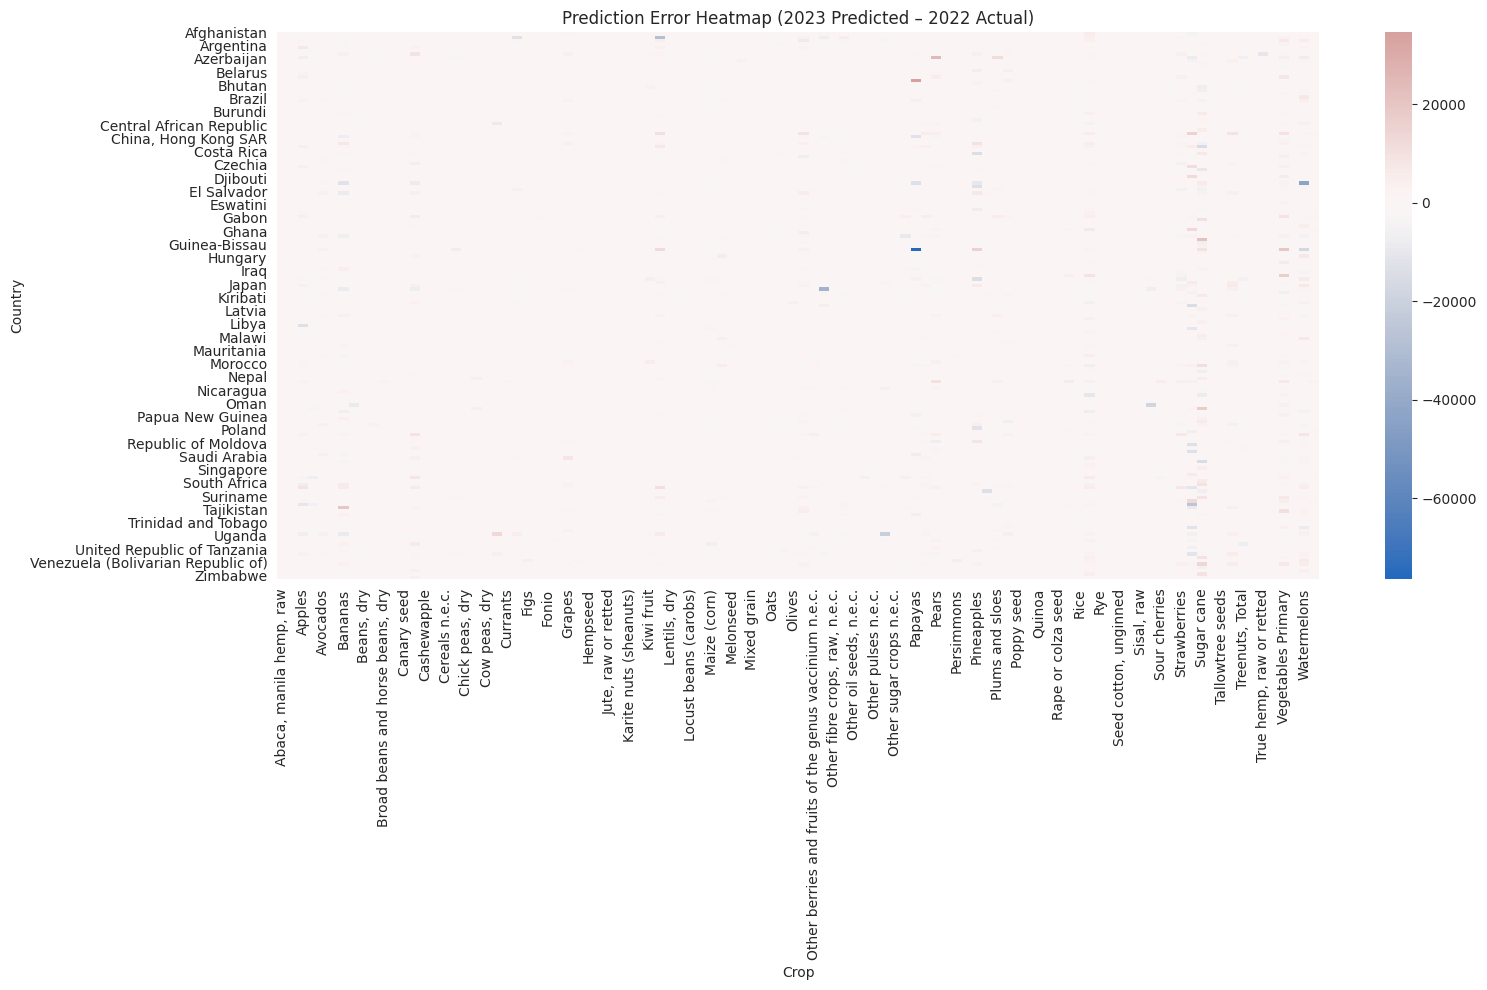

In [163]:
# Create error column
output_df['error'] = output_df['predicted_yield_2023'] - output_df['actual_yield_2022']

# Pivot table: country vs crop with average error
heatmap_data = output_df.pivot_table(
    index='country', columns='crop', values='error', aggfunc='mean'
).fillna(0)

# Plot
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, cmap='vlag', center=0)
plt.title("Prediction Error Heatmap (2023 Predicted – 2022 Actual)")
plt.xlabel("Crop")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


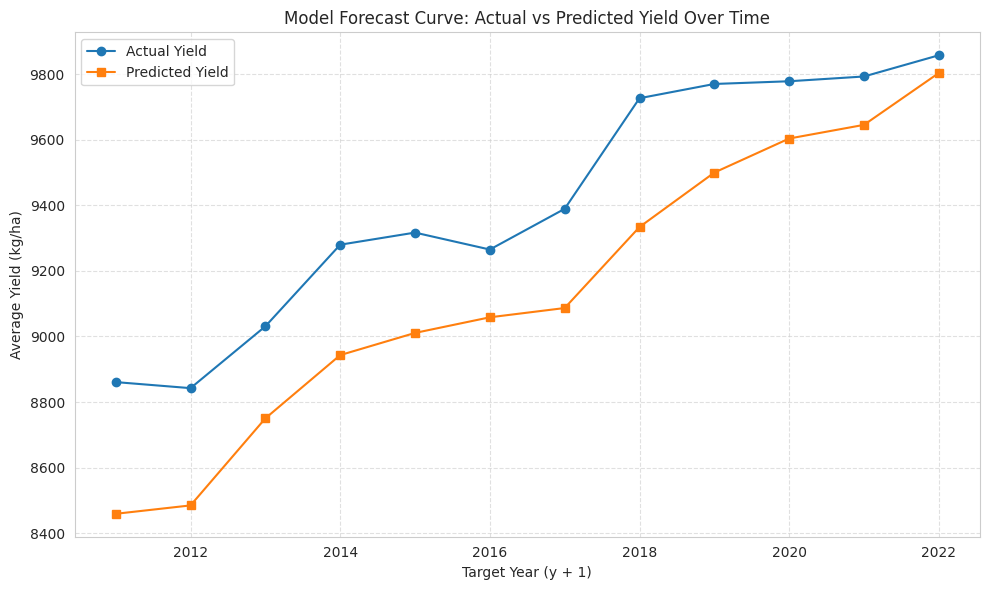

In [164]:
import matplotlib.pyplot as plt

# Group by target year and average
yearly = train_meta.groupby('target_year')[['actual_yield_next_year', 'predicted_yield_next_year']].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(yearly['target_year'], yearly['actual_yield_next_year'], marker='o', label='Actual Yield')
plt.plot(yearly['target_year'], yearly['predicted_yield_next_year'], marker='s', label='Predicted Yield')

plt.xlabel("Target Year (y + 1)")
plt.ylabel("Average Yield (kg/ha)")
plt.title("Model Forecast Curve: Actual vs Predicted Yield Over Time")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


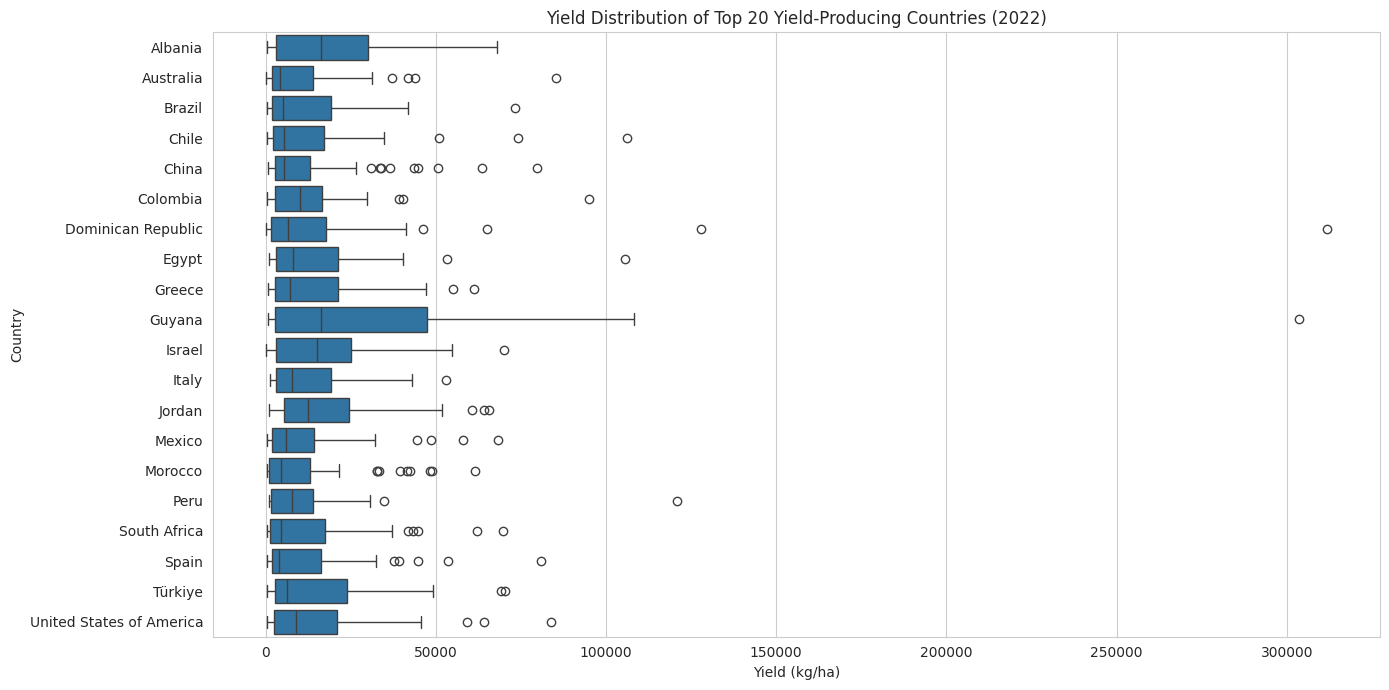

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Filter actual 2022 yields
df_2022 = final_df[final_df['year'] == 2022]

# Step 2: Get top 20 countries by total yield sum
top_countries = df_2022.groupby('country')['yield'].sum().sort_values(ascending=False).head(20).index

# Step 3: Filter for just those countries
top_df = df_2022[df_2022['country'].isin(top_countries)]

# Step 4: Plot
plt.figure(figsize=(14, 7))
sns.boxplot(data=top_df, x='yield', y='country', orient='h')
plt.title("Yield Distribution of Top 20 Yield-Producing Countries (2022)")
plt.xlabel("Yield (kg/ha)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


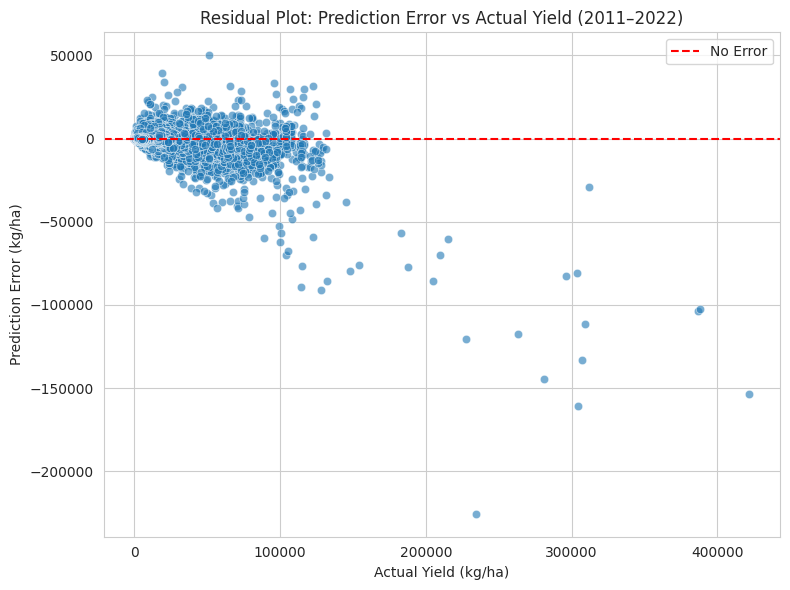

In [166]:
plt.figure(figsize=(8, 6))
residuals = df['predicted_yield_next_year'] - df['actual_yield_next_year']
sns.scatterplot(x='actual_yield_next_year', y=residuals, data=df, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', label='No Error')
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Prediction Error (kg/ha)")
plt.title("Residual Plot: Prediction Error vs Actual Yield (2011–2022)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
